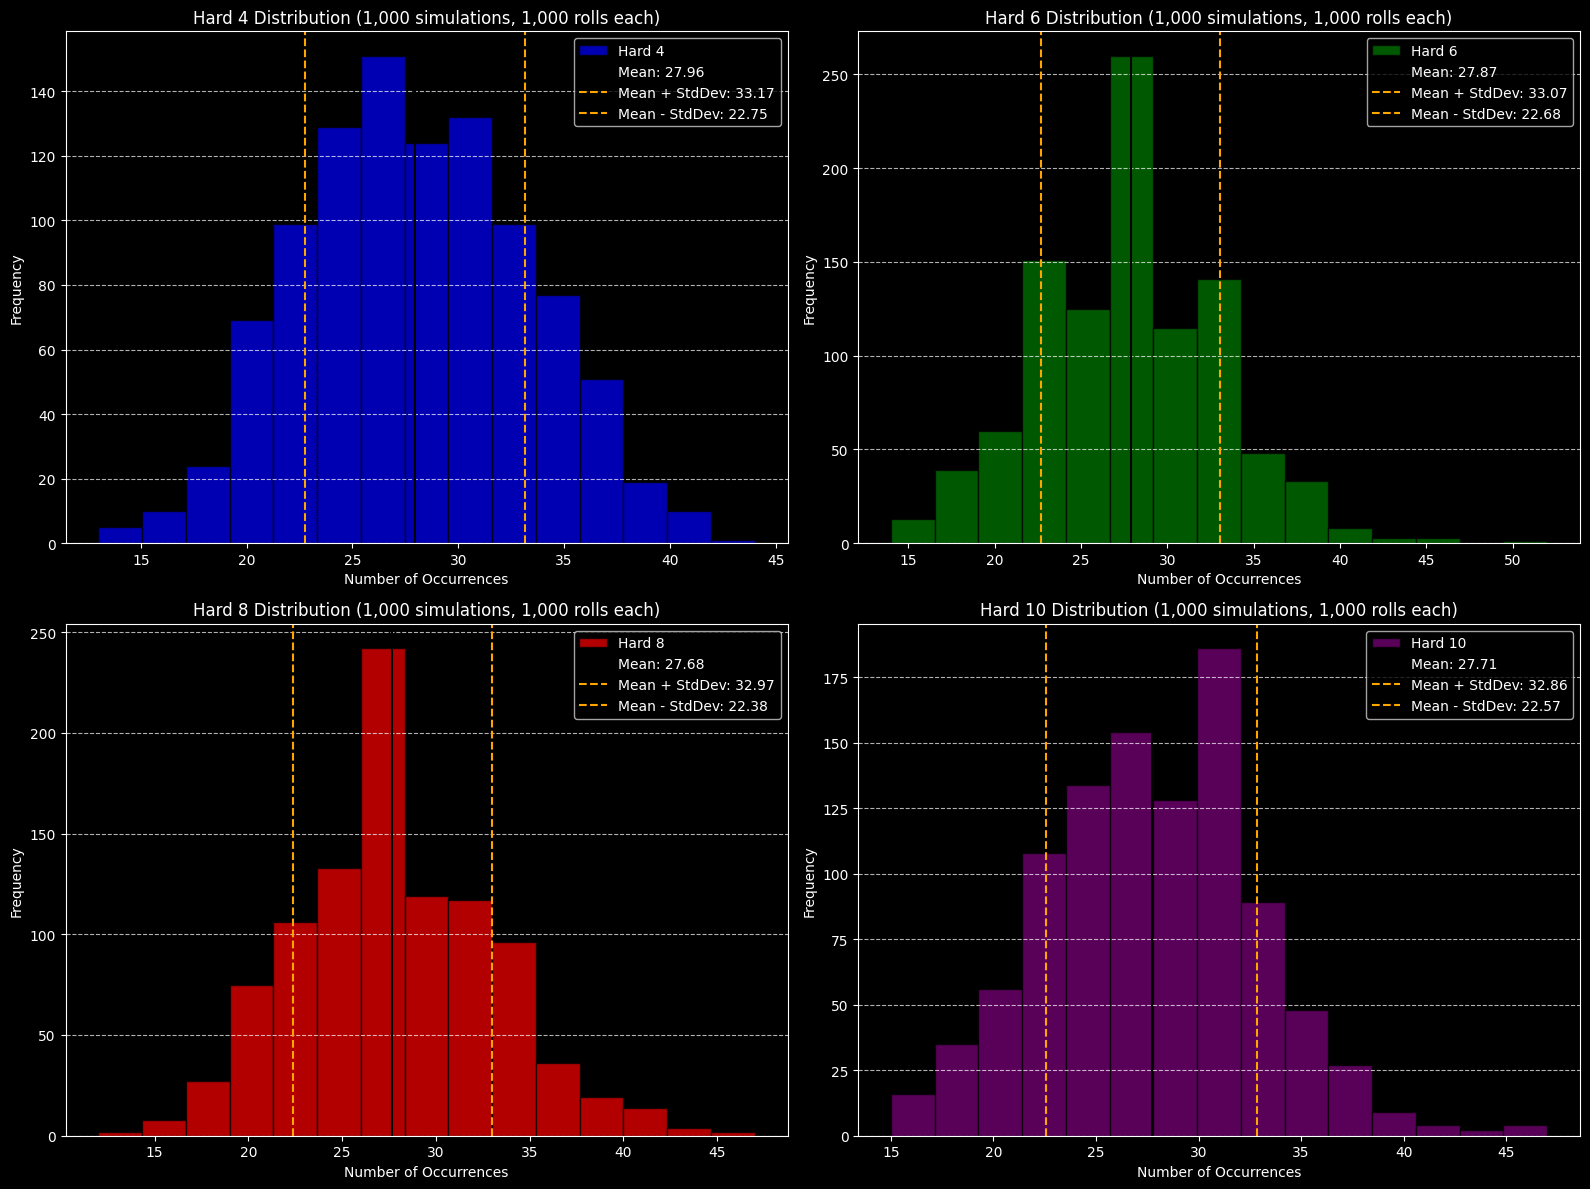

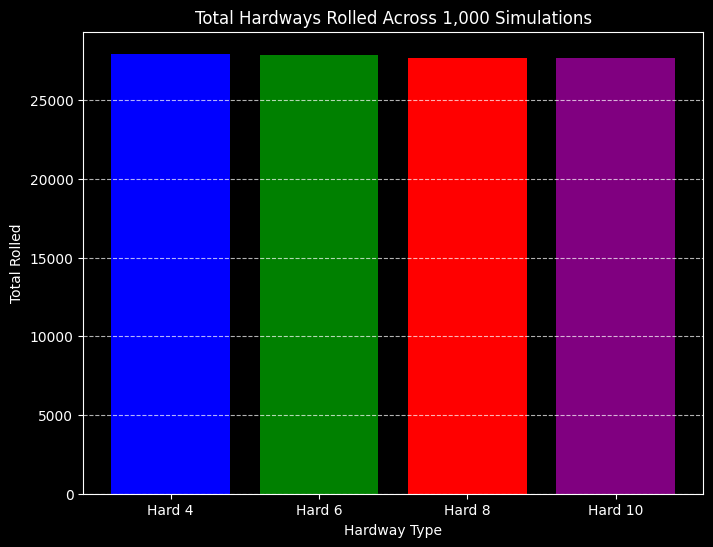

Total hardways rolled across all simulations:
Hard 4: 27959
Hard 6: 27873
Hard 8: 27678
Hard 10: 27712


In [ ]:
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

# Parameters
num_simulations = 1000
rolls_per_sim = 1000

# Generate all dice rolls at once on the GPU
first_die = cp.random.randint(1, 7, size=(
    num_simulations, rolls_per_sim), dtype=cp.int8)
second_die = cp.random.randint(1, 7, size=(
    num_simulations, rolls_per_sim), dtype=cp.int8)
dice_sum = first_die + second_die

# Find where dice match (hardways)
matches = (first_die == second_die)

# Hardway masks
hardway_4 = matches & (dice_sum == 4)
hardway_6 = matches & (dice_sum == 6)
hardway_8 = matches & (dice_sum == 8)
hardway_10 = matches & (dice_sum == 10)

# Count hardways per simulation (axis=1)
hard_4_counts = cp.sum(hardway_4, axis=1).get()
hard_6_counts = cp.sum(hardway_6, axis=1).get()
hard_8_counts = cp.sum(hardway_8, axis=1).get()
hard_10_counts = cp.sum(hardway_10, axis=1).get()

# Total hardways across all simulations
total_hardways = {
    "Hard 4": int(cp.sum(hardway_4).get()),
    "Hard 6": int(cp.sum(hardway_6).get()),
    "Hard 8": int(cp.sum(hardway_8).get()),
    "Hard 10": int(cp.sum(hardway_10).get()),
}

# Plot histograms for each hardway
hardway_data = [
    {"name": "Hard 4", "counts": hard_4_counts, "color": "blue", "index": 0},
    {"name": "Hard 6", "counts": hard_6_counts, "color": "green", "index": 1},
    {"name": "Hard 8", "counts": hard_8_counts, "color": "red", "index": 2},
    {"name": "Hard 10", "counts": hard_10_counts, "color": "purple", "index": 3}
]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for hw in hardway_data:
    ax = axs[hw["index"]]
    data = hw["counts"]
    mean_val = np.mean(data)
    std_val = np.std(data)
    ax.hist(data, bins=15, alpha=0.7,
            color=hw["color"], edgecolor="black", label=hw["name"])
    ax.axvline(mean_val, color='black', linestyle='-',
               label=f'Mean: {mean_val:.2f}')
    ax.axvline(mean_val + std_val, color='orange', linestyle='--',
               label=f'Mean + StdDev: {(mean_val + std_val):.2f}')
    ax.axvline(max(0, mean_val - std_val), color='orange', linestyle='--',
               label=f'Mean - StdDev: {max(0, mean_val - std_val):.2f}')
    ax.set_title(
        f'{hw["name"]} Distribution ({num_simulations:,} simulations, {rolls_per_sim:,} rolls each)')
    ax.set_xlabel('Number of Occurrences')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()

# Bar graph of total hardways rolled across all simulations
plt.figure(figsize=(8, 6))
plt.bar(total_hardways.keys(), total_hardways.values(),
        color=['blue', 'green', 'red', 'purple'])
plt.title(f'Total Hardways Rolled Across {num_simulations:,} Simulations')
plt.xlabel('Hardway Type')
plt.ylabel('Total Rolled')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Total hardways rolled across all simulations:")
for k, v in total_hardways.items():
    print(f"{k}: {v}")

# Clear GPU when finished running

del first_die, second_die, dice_sum, matches, hardway_4, hardway_6, hardway_8, hardway_10
cp._default_memory_pool.free_all_blocks()

In [2]:
import cupy
import numpy

mempool = cupy.get_default_memory_pool()
pinned_mempool = cupy.get_default_pinned_memory_pool()

print(mempool)